# Notebook 3 – Porto Seguro Safe Driver Prediction (Classification)

## Overview
We benchmark five tabular-learning methods on the Porto Seguro dataset:
**Tabular ResNet**, **FT-Transformer**, **XGBoost**, **LightGBM**, and **Random Forest**.  
Each model is tuned with **Optuna** (20 trials) and evaluated across 3 seeds.  
Metrics: **Accuracy**, **AUC-ROC**, **Normalized Gini** (= 2·AUC − 1), **F1**.

> **Note:** The dataset is heavily imbalanced (~3.6 % positives).  
> If the Kaggle API is not configured, a synthetic dataset matching the Porto
> Seguro schema is generated automatically.


In [1]:
# !pip install "rtdl==0.0.13" optuna xgboost lightgbm ucimlrepo scikit-learn pandas numpy matplotlib seaborn shap

## Imports

In [45]:
import warnings
warnings.filterwarnings('ignore')

import random, os, zipfile, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

import rtdl_revisiting_models
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


import time
import psutil
from torch.cuda.amp import GradScaler, autocast
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from sklearn.model_selection import train_test_split


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

torch.backends.cudnn.benchmark = True
print(f"cudnn.benchmark  = {torch.backends.cudnn.benchmark}")

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


Using device: cuda
cudnn.benchmark  = True


## Performance Optimizations & Bottleneck Tracking

Three changes are applied to speed up training:
1. **`cudnn.benchmark = True`** – lets cuDNN auto-select the fastest convolution algorithm.
2. **Automatic Mixed Precision (AMP)** – uses float16 for forward/backward on CUDA, nearly doubling throughput.
3. **Larger batch size (1,024)** – saturates GPU compute units and reduces per-sample kernel-launch overhead.

A `PhaseTimer` class tracks wall-clock time for each phase of the training loop so you can see exactly where time is spent.

In [3]:
class PhaseTimer:
    """Accumulates wall-clock time per named phase; prints a bottleneck breakdown."""
    def __init__(self):
        self._totals = {}
        self._counts = {}
        self._start  = {}

    def start(self, phase: str):
        if torch.cuda.is_available():
            torch.cuda.synchronize()   # flush GPU queue before timing
        self._start[phase] = time.perf_counter()

    def stop(self, phase: str):
        if torch.cuda.is_available():
            torch.cuda.synchronize()   # wait for GPU ops to finish
        elapsed = time.perf_counter() - self._start[phase]
        self._totals[phase] = self._totals.get(phase, 0.0) + elapsed
        self._counts[phase] = self._counts.get(phase, 0)   + 1

    def reset(self):
        self._totals.clear()
        self._counts.clear()
        self._start.clear()

    def report(self, label: str = ''):
        total = sum(self._totals.values())
        sep   = '─' * 60
        hdr   = f'Bottleneck Report{" – " + label if label else ""}'
        print(f'\n{sep}\n  {hdr}\n{sep}')
        for phase, t in sorted(self._totals.items(), key=lambda x: -x[1]):
            pct    = 100 * t / total if total > 0 else 0.0
            avg_ms = 1_000 * t / self._counts[phase]
            print(f'  {phase:<28s} {t:8.3f}s  {pct:5.1f}%  avg {avg_ms:8.2f}ms/call ({self._counts[phase]} calls)')
        print(f'  {"TOTAL":<28s} {total:8.3f}s  100.0%')
        print(f'{sep}\n')


def snapshot_resources(tag: str = ''):
    """Print a one-line snapshot of CPU and GPU resource usage."""
    cpu_pct = psutil.cpu_percent(interval=0.2)
    ram_gb  = psutil.virtual_memory().used / 1e9
    line    = f'[Resources{" – " + tag if tag else ""}]  CPU {cpu_pct:.1f}%  RAM {ram_gb:.2f} GB'
    if torch.cuda.is_available():
        alloc = torch.cuda.memory_allocated() / 1e9
        res   = torch.cuda.memory_reserved()  / 1e9
        line += f'  |  GPU-mem alloc {alloc:.2f} GB / reserved {res:.2f} GB'
    print(line)


# Shared timer used by the final training runs (not Optuna trials)
_global_timer = PhaseTimer()

print('✓ Performance utilities loaded')
snapshot_resources('startup')

✓ Performance utilities loaded
[Resources – startup]  CPU 26.5%  RAM 14.55 GB  |  GPU-mem alloc 0.00 GB / reserved 0.00 GB


In [4]:
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.backends.cudnn.version())

True
12.1
90100


## Configuration

In [5]:
SEEDS           = [42, 123, 456]
N_OPTUNA_TRIALS = 20
TEST_SIZE       = 0.20
VAL_FRAC        = 0.25


## Data Loading

In [6]:
os.makedirs('data/porto_seguro', exist_ok=True)
df = None
zip_path = 'data/porto-seguro-safe-driver-prediction.zip'

try:
    # Open the existing ZIP file and extract
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('data/porto_seguro')

    # Load the CSV directly
    csv_path = 'data/porto_seguro/train.csv'
    df = pd.read_csv(csv_path)
    print(f"Loaded real data: {df.shape}")

except Exception as e:
    print(f"Failed to read from local ZIP: {e}")
    print("Please make sure the file exists at:")
    print(zip_path)
    df = None

Loaded real data: (595212, 59)


## EDA

In [7]:
print("Shape:", df.shape)
print()
print("Target distribution:")
print(df['target'].value_counts())
print(f"Positive rate: {df['target'].mean():.3%}")


Shape: (595212, 59)

Target distribution:
target
0    573518
1     21694
Name: count, dtype: int64
Positive rate: 3.645%


In [8]:
df.columns

Index(['id', 'target', 'ps_ind_01', 'ps_ind_02_cat', 'ps_ind_03',
       'ps_ind_04_cat', 'ps_ind_05_cat', 'ps_ind_06_bin', 'ps_ind_07_bin',
       'ps_ind_08_bin', 'ps_ind_09_bin', 'ps_ind_10_bin', 'ps_ind_11_bin',
       'ps_ind_12_bin', 'ps_ind_13_bin', 'ps_ind_14', 'ps_ind_15',
       'ps_ind_16_bin', 'ps_ind_17_bin', 'ps_ind_18_bin', 'ps_reg_01',
       'ps_reg_02', 'ps_reg_03', 'ps_car_01_cat', 'ps_car_02_cat',
       'ps_car_03_cat', 'ps_car_04_cat', 'ps_car_05_cat', 'ps_car_06_cat',
       'ps_car_07_cat', 'ps_car_08_cat', 'ps_car_09_cat', 'ps_car_10_cat',
       'ps_car_11_cat', 'ps_car_11', 'ps_car_12', 'ps_car_13', 'ps_car_14',
       'ps_car_15', 'ps_calc_01', 'ps_calc_02', 'ps_calc_03', 'ps_calc_04',
       'ps_calc_05', 'ps_calc_06', 'ps_calc_07', 'ps_calc_08', 'ps_calc_09',
       'ps_calc_10', 'ps_calc_11', 'ps_calc_12', 'ps_calc_13', 'ps_calc_14',
       'ps_calc_15_bin', 'ps_calc_16_bin', 'ps_calc_17_bin', 'ps_calc_18_bin',
       'ps_calc_19_bin', 'ps_calc_20_bin'],


In [9]:
# Print the number of unique values in each column
print("Number of unique values in each column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")


Number of unique values in each column:
id: 595212
target: 2
ps_ind_01: 8
ps_ind_02_cat: 5
ps_ind_03: 12
ps_ind_04_cat: 3
ps_ind_05_cat: 8
ps_ind_06_bin: 2
ps_ind_07_bin: 2
ps_ind_08_bin: 2
ps_ind_09_bin: 2
ps_ind_10_bin: 2
ps_ind_11_bin: 2
ps_ind_12_bin: 2
ps_ind_13_bin: 2
ps_ind_14: 5
ps_ind_15: 14
ps_ind_16_bin: 2
ps_ind_17_bin: 2
ps_ind_18_bin: 2
ps_reg_01: 10
ps_reg_02: 19
ps_reg_03: 5013
ps_car_01_cat: 13
ps_car_02_cat: 3
ps_car_03_cat: 3
ps_car_04_cat: 10
ps_car_05_cat: 3
ps_car_06_cat: 18
ps_car_07_cat: 3
ps_car_08_cat: 2
ps_car_09_cat: 6
ps_car_10_cat: 3
ps_car_11_cat: 104
ps_car_11: 5
ps_car_12: 184
ps_car_13: 70482
ps_car_14: 850
ps_car_15: 15
ps_calc_01: 10
ps_calc_02: 10
ps_calc_03: 10
ps_calc_04: 6
ps_calc_05: 7
ps_calc_06: 11
ps_calc_07: 10
ps_calc_08: 11
ps_calc_09: 8
ps_calc_10: 26
ps_calc_11: 20
ps_calc_12: 11
ps_calc_13: 14
ps_calc_14: 24
ps_calc_15_bin: 2
ps_calc_16_bin: 2
ps_calc_17_bin: 2
ps_calc_18_bin: 2
ps_calc_19_bin: 2
ps_calc_20_bin: 2


In [10]:
# -1 values as missing indicator
n_neg1 = (df == -1).sum()
print("Columns with -1 (missing values):")
print(n_neg1[n_neg1 > 0])


Columns with -1 (missing values):
ps_ind_02_cat       216
ps_ind_04_cat        83
ps_ind_05_cat      5809
ps_reg_03        107772
ps_car_01_cat       107
ps_car_02_cat         5
ps_car_03_cat    411231
ps_car_05_cat    266551
ps_car_07_cat     11489
ps_car_09_cat       569
ps_car_11             5
ps_car_12             1
ps_car_14         42620
dtype: int64


In [11]:
# Find columns with high collinearity
corr_matrix = df.drop(columns=['id', 'target']).corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
collinear_pairs = [
    (col, row, upper_tri.loc[row, col])
    for col in upper_tri.columns
    for row in upper_tri.index
    if upper_tri.loc[row, col] > 0.9
]
print("Highly correlated column pairs (corr > 0.9):")
for pair in collinear_pairs:
    print(f"{pair[0]} - {pair[1]} : {pair[2]:.2f}")


Highly correlated column pairs (corr > 0.9):


## Preprocessing

In [12]:
df_proc = df.drop(columns=['id']).copy()
y = df_proc['target'].values.astype(np.int64)
df_feat = df_proc.drop(columns=['target'])

cat_cols_ps  = [c for c in df_feat.columns if c.endswith('_cat')]
num_cols_ps  = [c for c in df_feat.columns if c not in cat_cols_ps]

print(f"Numerical features: {len(num_cols_ps)}")
print(f"Categorical features: {len(cat_cols_ps)}")

# Replace -1 with NaN
df_feat[cat_cols_ps] = df_feat[cat_cols_ps].replace(-1, np.nan)
df_feat[num_cols_ps] = df_feat[num_cols_ps].replace(-1, np.nan)

# Impute
for col in cat_cols_ps:
    mode_val = df_feat[col].mode()
    if len(mode_val) > 0:
        df_feat[col] = df_feat[col].fillna(mode_val[0])
    else:
        df_feat[col] = df_feat[col].fillna(0)

for col in num_cols_ps:
    df_feat[col] = df_feat[col].fillna(df_feat[col].median())

print("Missing after imputation:", df_feat.isnull().sum().sum())


Numerical features: 43
Categorical features: 14
Missing after imputation: 0


In [13]:
# Define a threshold for "too many categories"
max_cardinality = 50   # adjust as needed

# Compute cardinalities
cat_cardinalities = df_feat[cat_cols_ps].nunique()

# Drop high-cardinality categorical columns
cat_cols_filtered = [col for col in cat_cols_ps if cat_cardinalities[col] <= max_cardinality]

print("Dropped high-cardinality columns:", [col for col in cat_cols_ps if col not in cat_cols_filtered])
print("Kept categorical columns:", cat_cols_filtered)

# One-hot encode the filtered categorical columns
onehot_enc_ps = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat_ohe = onehot_enc_ps.fit_transform(df_feat[cat_cols_filtered].astype(str)).astype(np.float32)

# Scale numerical variables
scaler_ps = StandardScaler()
X_num_ps = scaler_ps.fit_transform(df_feat[num_cols_ps].values.astype(np.float32))

# Combine: numerical (scaled) + OHE categorical (binary floats)
X_all_ps = np.concatenate([X_num_ps, X_cat_ohe], axis=1)

# Neural models treat all features as numerical; no separate categorical indices needed
cat_cards_ps = []
print("X_all shape:", X_all_ps.shape)
print(f"Numerical: {X_num_ps.shape[1]}, OHE categorical: {X_cat_ohe.shape[1]}")

Dropped high-cardinality columns: ['ps_car_11_cat']
Kept categorical columns: ['ps_ind_02_cat', 'ps_ind_04_cat', 'ps_ind_05_cat', 'ps_car_01_cat', 'ps_car_02_cat', 'ps_car_03_cat', 'ps_car_04_cat', 'ps_car_05_cat', 'ps_car_06_cat', 'ps_car_07_cat', 'ps_car_08_cat', 'ps_car_09_cat', 'ps_car_10_cat']
X_all shape: (595212, 114)
Numerical: 43, OHE categorical: 71


## Data Splitting (60 / 20 / 20)

In [14]:
idx = np.arange(len(y))
idx_tv, idx_test = train_test_split(idx, test_size=TEST_SIZE, random_state=42, stratify=y)
idx_train, idx_val = train_test_split(idx_tv, test_size=VAL_FRAC, random_state=42,
                                       stratify=y[idx_tv])

X_tr_all, X_v_all, X_te_all = X_all_ps[idx_train], X_all_ps[idx_val], X_all_ps[idx_test]

# With OHE, the full matrix is the numerical input for neural models
X_tr_num, X_v_num, X_te_num = X_tr_all, X_v_all, X_te_all
# No separate integer-coded categorical indices needed
X_tr_cat = X_v_cat = X_te_cat = None

y_train_ps, y_val_ps, y_test_ps = y[idx_train], y[idx_val], y[idx_test]

sc_ps = StandardScaler()
X_tr_sc = sc_ps.fit_transform(X_tr_all)
X_v_sc  = sc_ps.transform(X_v_all)
X_te_sc = sc_ps.transform(X_te_all)

spw = float((y_train_ps == 0).sum()) / float((y_train_ps == 1).sum())
print(f"Train: {X_tr_sc.shape}, Val: {X_v_sc.shape}, Test: {X_te_sc.shape}")
print(f"scale_pos_weight = {spw:.2f}")

Train: (357126, 114), Val: (119043, 114), Test: (119043, 114)
scale_pos_weight = 26.44


## Helper Functions

In [49]:
def set_seed(seed):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
 
 
def compute_porto_metrics(y_true, y_pred, y_prob):
    from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
    acc  = accuracy_score(y_true, y_pred)
    auc  = roc_auc_score(y_true, y_prob)
    gini = 2 * auc - 1
    f1   = f1_score(y_true, y_pred, zero_division=0)
    return acc, auc, gini, f1
 
 
def _make_scaler(device_str, enabled):
    """Create a GradScaler that works with both old and new PyTorch."""
    try:                                           # PyTorch ≥ 2.1
        return torch.amp.GradScaler(device_str, enabled=enabled)
    except TypeError:                              # older PyTorch
        from torch.cuda.amp import GradScaler
        return GradScaler(enabled=enabled)
 
 
def train_ft_transformer(
        model, X_num_tr, X_cat_tr, y_tr,
        X_num_v,  X_cat_v,  y_v,
        lr=1e-3, n_epochs=100, batch_size=256,
        val_batch_size=512,
        task='regression', device_='cpu',
        use_amp=True, phase_timer=None):
 
    model = model.to(device_)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.MSELoss() if task == 'regression' else nn.BCEWithLogitsLoss()
 
    _amp_on = use_amp and device_ != 'cpu' and torch.cuda.is_available()
    scaler  = _make_scaler(device_, _amp_on)
 
    # ── All data stays on CPU; batches are moved to GPU as needed ─────────
    X_num_tr_t = torch.FloatTensor(X_num_tr)
    X_cat_tr_t = torch.LongTensor(X_cat_tr)  if X_cat_tr is not None else None
    y_tr_t     = torch.FloatTensor(y_tr.astype(np.float32))
    X_num_v_t  = torch.FloatTensor(X_num_v)
    X_cat_v_t  = torch.LongTensor(X_cat_v)   if X_cat_v  is not None else None
    y_v_t      = torch.FloatTensor(y_v.astype(np.float32))
 
    train_losses, val_losses = [], []
    best_val   = float('inf')
    best_state = None           # stored on CPU to save GPU headroom
    patience   = 10
    pat_cnt    = 0
    t0_train   = time.perf_counter()
    total_samples = 0
 
    for epoch in range(n_epochs):
        model.train()
        n = len(X_num_tr_t)
 
        if phase_timer: phase_timer.start('data_shuffle')
        idx_e = torch.randperm(n)
        if phase_timer: phase_timer.stop('data_shuffle')
 
        ep_loss = 0.0
        for i in range(0, n, batch_size):
            b = idx_e[i : i + batch_size]
 
            if phase_timer: phase_timer.start('batch_index')
            xn = X_num_tr_t[b].to(device_, non_blocking=True)
            xc = X_cat_tr_t[b].to(device_, non_blocking=True) \
                 if X_cat_tr_t is not None else None
            yb = y_tr_t[b].to(device_, non_blocking=True)
            if phase_timer: phase_timer.stop('batch_index')
 
            optimizer.zero_grad(set_to_none=True)
 
            if phase_timer: phase_timer.start('forward')
            with torch.amp.autocast(device_, enabled=_amp_on):
                out  = model(xn, xc).squeeze(-1)
                loss = criterion(out, yb)
            if phase_timer: phase_timer.stop('forward')
 
            if phase_timer: phase_timer.start('backward')
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            if phase_timer: phase_timer.stop('backward')
 
            ep_loss       += loss.item() * len(b)
            total_samples += len(b)
 
        # ── BATCHED validation ─────────────────────────────────────────────
        # FT-Transformer attention is O(batch × tokens²).
        # Passing all 119 K val samples at once → ~12 GB → OOM.
        # Processing in chunks of val_batch_size keeps each chunk ≤ 54 MB.
        if phase_timer: phase_timer.start('validation')
        model.eval()
        val_loss_acc = 0.0
        n_v = len(X_num_v_t)
        with torch.no_grad():
            for j in range(0, n_v, val_batch_size):
                xn_v = X_num_v_t[j : j + val_batch_size].to(device_, non_blocking=True)
                xc_v = (X_cat_v_t[j : j + val_batch_size].to(device_, non_blocking=True)
                        if X_cat_v_t is not None else None)
                yb_v = y_v_t[j : j + val_batch_size].to(device_, non_blocking=True)
                with torch.amp.autocast(device_, enabled=_amp_on):
                    vout = model(xn_v, xc_v).squeeze(-1)
                    val_loss_acc += criterion(vout, yb_v).item() * len(xn_v)
        vloss = val_loss_acc / n_v
        if phase_timer: phase_timer.stop('validation')
 
        train_losses.append(ep_loss / n)
        val_losses.append(vloss)
 
        if vloss < best_val:
            best_val   = vloss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            pat_cnt    = 0
        else:
            pat_cnt += 1
        if pat_cnt >= patience:
            break
 
    elapsed    = time.perf_counter() - t0_train
    throughput = total_samples / elapsed
    print(f'    [train_ft] {len(train_losses)} epochs | {elapsed:.1f}s | '
          f'{throughput:,.0f} samples/s | AMP={"on" if _amp_on else "off"}')
 
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, train_losses, val_losses
 
 
def predict_ft_transformer(model, X_num, X_cat, device_, batch_size=512):
    """Batched inference — same memory budget as training."""
    model.eval()
    model   = model.to(device_)
    X_num_t = torch.FloatTensor(X_num)
    X_cat_t = torch.LongTensor(X_cat) if X_cat is not None else None
    _amp_on = device_ != 'cpu' and torch.cuda.is_available()
    preds   = []
    with torch.no_grad():
        for i in range(0, len(X_num_t), batch_size):
            xn = X_num_t[i : i + batch_size].to(device_, non_blocking=True)
            xc = (X_cat_t[i : i + batch_size].to(device_, non_blocking=True)
                  if X_cat_t is not None else None)
            with torch.amp.autocast(device_, enabled=_amp_on):
                out = model(xn, xc).squeeze(-1)
            preds.append(out.cpu().numpy())
    return np.concatenate(preds)
 

## Model 1: Tabular ResNet

In [19]:
class ResNetWrapper(nn.Module):
    """Tabular ResNet that accepts (x_num, x_cat) signature.
    With one-hot-encoded features all inputs are numerical; x_cat is ignored.
    """
    def __init__(self, d_in, d_out, n_blocks, d_block,
                 d_hidden=None, d_hidden_multiplier=None,
                 dropout1=0.0, dropout2=0.0):
        super().__init__()
        self.resnet = rtdl_revisiting_models.ResNet(
            d_in=d_in, d_out=d_out,
            n_blocks=n_blocks, d_block=d_block,
            d_hidden=d_hidden, d_hidden_multiplier=d_hidden_multiplier,
            dropout1=dropout1, dropout2=dropout2,
        )

    def forward(self, x_num, x_cat=None):
        return self.resnet(x_num)
    


# ── torch.profiler: identify per-op CPU/CUDA bottlenecks ────────────────────────
# Runs a short 6-step forward+backward pass on a small ResNet and prints the
# top operations by self-CPU time and self-CUDA time.
# TensorBoard traces are written to /tmp/profiler_trace for detailed inspection.

set_seed(42)
n_num_ps = X_tr_num.shape[1]
_pm = ResNetWrapper(d_in=n_num_ps, d_out=1,
                    n_blocks=2, d_block=128, d_hidden=256,
                    dropout1=0.1, dropout2=0.1).to(device)
_po = optim.AdamW(_pm.parameters(), lr=1e-3)
_pc = nn.BCEWithLogitsLoss()
_px = torch.FloatTensor(X_tr_num[:2048]).to(device)
_py = torch.FloatTensor(y_train_ps[:2048].astype(np.float32)).to(device)
_amp_on_prof = (str(device) != 'cpu' and torch.cuda.is_available())
_scaler_prof = GradScaler(enabled=_amp_on_prof)

prof_activities = [torch.profiler.ProfilerActivity.CPU]
if torch.cuda.is_available():
    prof_activities.append(torch.profiler.ProfilerActivity.CUDA)

with torch.profiler.profile(
    activities=prof_activities,
    schedule=torch.profiler.schedule(wait=1, warmup=2, active=3, repeat=1),
    on_trace_ready=torch.profiler.tensorboard_trace_handler('/tmp/profiler_trace'),
    record_shapes=True,
    profile_memory=True,
    with_stack=False,
) as prof:
    for _step in range(6):
        _pm.train()
        _po.zero_grad(set_to_none=True)
        with autocast(enabled=_amp_on_prof):
            _out  = _pm(_px, None).squeeze(-1)
            _loss = _pc(_out, _py)
        _scaler_prof.scale(_loss).backward()
        _scaler_prof.step(_po)
        _scaler_prof.update()
        prof.step()

print('─── torch.profiler: Top-15 ops by self CPU time ───')
print(prof.key_averages().table(sort_by='self_cpu_time_total', row_limit=15))
if torch.cuda.is_available():
    print('─── torch.profiler: Top-15 ops by self CUDA time ──')
    print(prof.key_averages().table(sort_by='self_cuda_time_total', row_limit=15))

snapshot_resources('after profiler')
del _pm, _po, _pc, _px, _py, _scaler_prof


─── torch.profiler: Top-15 ops by self CPU time ───
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*        43.33%      45.611ms        72.87%      76.705ms      25.568ms      44.924ms        42.16%      76.651ms      25.550ms   

In [21]:
all_results = []

n_num_ps = X_tr_num.shape[1]  # full feature count (numerical + OHE categorical)

def resnet_porto_objective(trial):
    n_blocks  = trial.suggest_int('n_blocks', 1, 4)
    d_block   = trial.suggest_categorical('d_block', [64, 128, 256])
    d_hidden  = trial.suggest_categorical('d_hidden', [128, 256, 512])
    dropout1  = trial.suggest_float('dropout1', 0.0, 0.5)
    dropout2  = trial.suggest_float('dropout2', 0.0, 0.5)
    lr        = trial.suggest_float('lr', 1e-4, 1e-3, log=True)

    set_seed(42)
    model = ResNetWrapper(
        d_in=n_num_ps, d_out=1,
        n_blocks=n_blocks, d_block=d_block,
        d_hidden=d_hidden,
        dropout1=dropout1, dropout2=dropout2,
    )

    model, _, _ = train_ft_transformer(
        model, X_tr_num, None, y_train_ps,
        X_v_num, None, y_val_ps,
        lr=lr, n_epochs=50, batch_size=1024,
        task='classification', device_=str(device)
    )

    raw  = predict_ft_transformer(model, X_v_num, None, str(device))
    prob = torch.sigmoid(torch.tensor(raw)).numpy()
    return -roc_auc_score(y_val_ps, prob)


study_rn = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=42))
study_rn.optimize(resnet_porto_objective, n_trials=N_OPTUNA_TRIALS)
best_rn = study_rn.best_params
print(f"Best Tabular ResNet params: {best_rn}")

    [train_ft] 36 epochs | 40.9s | 314,074 samples/s | AMP=on
    [train_ft] 32 epochs | 29.0s | 394,388 samples/s | AMP=on
    [train_ft] 34 epochs | 51.1s | 237,724 samples/s | AMP=on
    [train_ft] 19 epochs | 30.8s | 220,113 samples/s | AMP=on
    [train_ft] 25 epochs | 26.9s | 332,346 samples/s | AMP=on
    [train_ft] 13 epochs | 25.8s | 180,157 samples/s | AMP=on
    [train_ft] 16 epochs | 20.8s | 274,902 samples/s | AMP=on
    [train_ft] 13 epochs | 24.6s | 188,741 samples/s | AMP=on
    [train_ft] 50 epochs | 93.4s | 191,258 samples/s | AMP=on
    [train_ft] 23 epochs | 21.7s | 378,530 samples/s | AMP=on
    [train_ft] 16 epochs | 17.7s | 323,685 samples/s | AMP=on
    [train_ft] 16 epochs | 18.0s | 317,284 samples/s | AMP=on
    [train_ft] 16 epochs | 19.0s | 301,147 samples/s | AMP=on
    [train_ft] 16 epochs | 17.3s | 329,370 samples/s | AMP=on
    [train_ft] 17 epochs | 24.1s | 252,265 samples/s | AMP=on
    [train_ft] 17 epochs | 24.5s | 248,246 samples/s | AMP=on
    [tra

In [23]:
print("Trials done:", len(study_rn.trials))
print("Best AUC:", -study_rn.best_value)
print("Best params:", study_rn.best_params)

Trials done: 20
Best AUC: 0.6365435702781151
Best params: {'n_blocks': 2, 'd_block': 128, 'd_hidden': 256, 'dropout1': 0.40109849037701983, 'dropout2': 0.03727532183988541, 'lr': 0.0009702573394120733}


In [83]:
print("Training Tabular ResNet across seeds...")
rn_train_curves = {}
for seed in SEEDS:
    set_seed(seed)
    model = ResNetWrapper(
        d_in=n_num_ps, d_out=1,
        n_blocks=best_rn['n_blocks'], d_block=best_rn['d_block'],
        d_hidden=best_rn['d_hidden'],
        dropout1=best_rn['dropout1'], dropout2=best_rn['dropout2'],
    )
    model, tr_l, va_l = train_ft_transformer(
        model, X_tr_num, None, y_train_ps,
        X_v_num, None, y_val_ps,
        lr=best_rn['lr'], n_epochs=100, batch_size=1024,
        task='classification', device_=str(device), phase_timer=_global_timer
    )
    rn_train_curves[seed] = (tr_l, va_l)

    # --- Threshold tuning on validation ---
    val_raw  = predict_ft_transformer(model, X_v_num, None, str(device))
    val_prob = torch.sigmoid(torch.tensor(val_raw)).numpy()
    thresholds = np.linspace(0.02, 0.98, 49)
    f1_scores = [f1_score(y_val_ps, (val_prob >= t).astype(int)) for t in thresholds]
    best_t = thresholds[np.argmax(f1_scores)]

    # --- Apply best threshold to test ---
    raw  = predict_ft_transformer(model, X_te_num, None, str(device))
    prob = torch.sigmoid(torch.tensor(raw)).numpy()
    pred = (prob >= best_t).astype(int)

    acc, auc, gini, f1 = compute_porto_metrics(y_test_ps, pred, prob)
    all_results.append({
        'method': 'TabularResNet', 'seed': seed,
        'accuracy': acc, 'auc': auc, 'gini': gini, 'f1': f1, 'threshold': best_t
    })
    print(f"  Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, Gini={gini:.4f}, F1={f1:.4f} (thr={best_t:.2f})")


Training Tabular ResNet across seeds...
    [train_ft] 16 epochs | 27.7s | 206,043 samples/s | AMP=on
  Seed 42: Acc=0.8687, AUC=0.6311, Gini=0.2622, F1=0.1086 (thr=0.06)
    [train_ft] 16 epochs | 28.0s | 204,118 samples/s | AMP=on
  Seed 123: Acc=0.8434, AUC=0.6295, Gini=0.2589, F1=0.1088 (thr=0.06)
    [train_ft] 18 epochs | 26.9s | 238,924 samples/s | AMP=on
  Seed 456: Acc=0.8481, AUC=0.6317, Gini=0.2634, F1=0.1104 (thr=0.06)


In [25]:
_global_timer.report('Tabular ResNet – final training (3 seeds)')
_global_timer.reset()
snapshot_resources('after ResNet training')



────────────────────────────────────────────────────────────
  Bottleneck Report – Tabular ResNet – final training (3 seeds)
────────────────────────────────────────────────────────────
  backward                       39.850s   64.7%  avg     2.28ms/call (17450 calls)
  forward                        18.878s   30.6%  avg     1.08ms/call (17450 calls)
  batch_index                     2.460s    4.0%  avg     0.14ms/call (17450 calls)
  validation                      0.340s    0.6%  avg     6.79ms/call (50 calls)
  data_shuffle                    0.110s    0.2%  avg     2.21ms/call (50 calls)
  TOTAL                          61.638s  100.0%
────────────────────────────────────────────────────────────

[Resources – after ResNet training]  CPU 7.2%  RAM 13.43 GB  |  GPU-mem alloc 0.02 GB / reserved 0.79 GB


## Model 2: FT-Transformer

In [47]:
torch.cuda.empty_cache()

In [50]:
def _cleanup_gpu(study, trial):
    """Optuna callback: free GPU cache after every trial."""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()
 
 
def ft_porto_objective(trial):
    d_block   = trial.suggest_categorical('d_block',           [64, 128])
    n_blocks  = trial.suggest_int        ('n_blocks',           1, 3)
    attn_heads= trial.suggest_categorical('attention_n_heads',  [2, 4])
    ffn_mult  = trial.suggest_float      ('ffn_d_hidden_multiplier', 1.0, 1.5)
    attn_drop = trial.suggest_float      ('attention_dropout',  0.0, 0.3)
    ffn_drop  = trial.suggest_float      ('ffn_dropout',        0.0, 0.3)
    lr        = trial.suggest_float      ('lr', 1e-4, 5e-4, log=True)
 
    set_seed(42)
 
    # ── Use the direct constructor (make_baseline does not exist here) ────
    model = rtdl_revisiting_models.FTTransformer(
        n_cont_features      = n_num_ps,
        cat_cardinalities    = cat_cards_ps,   # [] when OHE pipeline is used
        d_block              = d_block,
        n_blocks             = n_blocks,
        attention_n_heads    = attn_heads,
        ffn_d_hidden_multiplier = ffn_mult,
        attention_dropout    = attn_drop,
        ffn_dropout          = ffn_drop,
        residual_dropout     = 0.0,
        d_out                = 1,
    )
 
    model, _, _ = train_ft_transformer(
        model, X_tr_num, X_tr_cat, y_train_ps,
        X_v_num,  X_v_cat,  y_val_ps,
        lr             = lr,
        n_epochs       = 50,
        batch_size     = 256,
        val_batch_size = 512,
        task           = 'classification',
        device_        = str(device),
    )
 
    raw  = predict_ft_transformer(model, X_v_num, X_v_cat, str(device), batch_size=512)
    prob = torch.sigmoid(torch.tensor(raw)).numpy()
 
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()
 
    return -roc_auc_score(y_val_ps, prob)
 
 
# Clean slate, then run
torch.cuda.empty_cache(); gc.collect()
 
study_ft = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
study_ft.optimize(
    ft_porto_objective,
    n_trials       = N_OPTUNA_TRIALS,
    catch          = (torch.cuda.OutOfMemoryError,),  # skip OOM trials gracefully
    callbacks      = [_cleanup_gpu],
    gc_after_trial = True,
)
 
best_ft = study_ft.best_params
print(f"Best FT-Transformer params: {best_ft}")
 

    [train_ft] 31 epochs | 707.4s | 15,651 samples/s | AMP=on
    [train_ft] 20 epochs | 342.6s | 20,851 samples/s | AMP=on
    [train_ft] 28 epochs | 368.6s | 27,131 samples/s | AMP=on
    [train_ft] 33 epochs | 262.1s | 44,958 samples/s | AMP=on
    [train_ft] 18 epochs | 320.2s | 20,078 samples/s | AMP=on
    [train_ft] 36 epochs | 460.0s | 27,946 samples/s | AMP=on
    [train_ft] 24 epochs | 189.0s | 45,356 samples/s | AMP=on
    [train_ft] 43 epochs | 565.7s | 27,144 samples/s | AMP=on
    [train_ft] 39 epochs | 978.0s | 14,241 samples/s | AMP=on
    [train_ft] 42 epochs | 301.5s | 49,747 samples/s | AMP=on
    [train_ft] 46 epochs | 569.1s | 28,869 samples/s | AMP=on
    [train_ft] 24 epochs | 287.9s | 29,766 samples/s | AMP=on
    [train_ft] 34 epochs | 414.2s | 29,318 samples/s | AMP=on
    [train_ft] 25 epochs | 298.8s | 29,884 samples/s | AMP=on
    [train_ft] 28 epochs | 337.2s | 29,654 samples/s | AMP=on
    [train_ft] 39 epochs | 272.8s | 51,058 samples/s | AMP=on
    [tra

In [51]:
print("Trials done:", len(study_ft.trials))
print("Best AUC:", -study_ft.best_value)
print("Best params:", study_ft.best_params)

Trials done: 20
Best AUC: 0.641629125158316
Best params: {'d_block': 64, 'n_blocks': 2, 'attention_n_heads': 2, 'ffn_d_hidden_multiplier': 1.4775465158294638, 'attention_dropout': 0.21666666503700235, 'ffn_dropout': 0.17545394921804489, 'lr': 0.00047856066798978984}


In [84]:
print("Training FT-Transformer across seeds...")
ft_train_curves = {}
 
for seed in SEEDS:
    torch.cuda.empty_cache(); gc.collect()
    set_seed(seed)
 
    model = rtdl_revisiting_models.FTTransformer(
        n_cont_features         = n_num_ps,
        cat_cardinalities       = cat_cards_ps,
        d_block                 = best_ft['d_block'],
        n_blocks                = best_ft['n_blocks'],
        attention_n_heads       = best_ft['attention_n_heads'],
        ffn_d_hidden_multiplier = best_ft['ffn_d_hidden_multiplier'],
        attention_dropout       = best_ft['attention_dropout'],
        ffn_dropout             = best_ft['ffn_dropout'],
        residual_dropout        = 0.0,
        d_out                   = 1,
    )
 
    model, tr_l, va_l = train_ft_transformer(
        model, X_tr_num, X_tr_cat, y_train_ps,
        X_v_num,  X_v_cat,  y_val_ps,
        lr             = best_ft['lr'],
        n_epochs       = 100,
        batch_size     = 256,
        val_batch_size = 512,
        task           = 'classification',
        device_        = str(device),
        phase_timer    = _global_timer,
    )
    ft_train_curves[seed] = (tr_l, va_l)
 
    # --- Threshold tuning on validation ---
    val_raw  = predict_ft_transformer(model, X_v_num, X_v_cat, str(device), batch_size=512)
    val_prob = torch.sigmoid(torch.tensor(val_raw)).numpy()
    thresholds = np.linspace(0.02, 0.98, 49)
    f1_scores = [f1_score(y_val_ps, (val_prob >= t).astype(int)) for t in thresholds]
    best_t = thresholds[np.argmax(f1_scores)]
 
    # --- Apply best threshold to test ---
    raw  = predict_ft_transformer(model, X_te_num, X_te_cat, str(device), batch_size=512)
    prob = torch.sigmoid(torch.tensor(raw)).numpy()
    pred = (prob >= best_t).astype(int)

    acc, auc, gini, f1 = compute_porto_metrics(y_test_ps, pred, prob)
    all_results.append({
        'method': 'FT-Transformer', 'seed': seed,
        'accuracy': acc, 'auc': auc, 'gini': gini, 'f1': f1,
        'threshold': best_t,
    })
    print(f"  Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, "
          f"Gini={gini:.4f}, F1={f1:.4f} (thr={best_t:.2f})")
 
    del model
    torch.cuda.empty_cache(); gc.collect()

Training FT-Transformer across seeds...
    [train_ft] 46 epochs | 604.3s | 27,183 samples/s | AMP=on
  Seed 42: Acc=0.8761, AUC=0.6365, Gini=0.2730, F1=0.1168 (thr=0.06)
    [train_ft] 31 epochs | 443.7s | 24,954 samples/s | AMP=on
  Seed 123: Acc=0.8646, AUC=0.6361, Gini=0.2722, F1=0.1131 (thr=0.06)
    [train_ft] 32 epochs | 539.4s | 21,187 samples/s | AMP=on
  Seed 456: Acc=0.8799, AUC=0.6369, Gini=0.2737, F1=0.1163 (thr=0.06)


In [53]:
_global_timer.report('FT-Transformer – final training (3 seeds)')
_global_timer.reset()
snapshot_resources('after FT-Transformer training')



────────────────────────────────────────────────────────────
  Bottleneck Report – FT-Transformer – final training (3 seeds)
────────────────────────────────────────────────────────────
  backward                     1044.085s   61.3%  avg     6.86ms/call (152164 calls)
  forward                       510.071s   30.0%  avg     3.35ms/call (152164 calls)
  validation                     95.779s    5.6%  avg   878.71ms/call (109 calls)
  batch_index                    51.685s    3.0%  avg     0.34ms/call (152164 calls)
  data_shuffle                    0.317s    0.0%  avg     2.91ms/call (109 calls)
  TOTAL                        1701.937s  100.0%
────────────────────────────────────────────────────────────

[Resources – after FT-Transformer training]  CPU 11.0%  RAM 13.79 GB  |  GPU-mem alloc 0.02 GB / reserved 0.03 GB


## Model 3: XGBoost

In [54]:
def xgb_porto_objective(trial):
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 100, 500),
        'max_depth':       trial.suggest_int('max_depth', 3, 8),
        'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':       trial.suggest_float('subsample', 0.6, 1.0),
        'scale_pos_weight': spw,
        'random_state':    42
    }
    set_seed(42)
    m = xgb.XGBClassifier(**params, verbosity=0, use_label_encoder=False,
                           eval_metric='auc')
    m.fit(X_tr_all, y_train_ps)
    prob = m.predict_proba(X_v_all)[:, 1]
    return -roc_auc_score(y_val_ps, prob)

study_xgb = optuna.create_study(direction='minimize',
                                  sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(xgb_porto_objective, n_trials=N_OPTUNA_TRIALS)
best_xgb = study_xgb.best_params
print(f"Best XGBoost params: {best_xgb}")


Best XGBoost params: {'n_estimators': 433, 'max_depth': 4, 'learning_rate': 0.01855998084649059, 'subsample': 0.6733618039413735}


In [58]:
print("Trials done:", len(study_xgb.trials))
print("Best AUC:", -study_xgb.best_value)
print("Best params:", study_xgb.best_params)

Trials done: 20
Best AUC: 0.6433262326260626
Best params: {'n_estimators': 433, 'max_depth': 4, 'learning_rate': 0.01855998084649059, 'subsample': 0.6733618039413735}


In [55]:
print("Training XGBoost across seeds...")
xgb_model_last = None
for seed in SEEDS:
    set_seed(seed)
    m = xgb.XGBClassifier(**best_xgb, scale_pos_weight=spw,
                           random_state=seed, verbosity=0,
                           use_label_encoder=False, eval_metric='auc')
    m.fit(X_tr_all, y_train_ps)
    preds = m.predict(X_te_all)
    probs = m.predict_proba(X_te_all)[:, 1]
    acc, auc, gini, f1 = compute_porto_metrics(y_test_ps, preds, probs)
    all_results.append({'method': 'XGBoost', 'seed': seed,
                        'accuracy': acc, 'auc': auc, 'gini': gini, 'f1': f1})
    xgb_model_last = m
    print(f"  Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, Gini={gini:.4f}, F1={f1:.4f}")


Training XGBoost across seeds...
  Seed 42: Acc=0.6359, AUC=0.6387, Gini=0.2773, F1=0.1007
  Seed 123: Acc=0.6366, AUC=0.6382, Gini=0.2763, F1=0.0999
  Seed 456: Acc=0.6359, AUC=0.6391, Gini=0.2781, F1=0.1004


## Model 4: LightGBM

In [56]:
def lgb_porto_objective(trial):
    params = {
        'n_estimators':  trial.suggest_int('n_estimators', 100, 500),
        'num_leaves':    trial.suggest_int('num_leaves', 20, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'random_state':  42, 'verbose': -1, 'is_unbalance': True
    }
    m = lgb.LGBMClassifier(**params)
    m.fit(X_tr_all, y_train_ps)
    prob = m.predict_proba(X_v_all)[:, 1]
    return -roc_auc_score(y_val_ps, prob)

study_lgb = optuna.create_study(direction='minimize',
                                  sampler=optuna.samplers.TPESampler(seed=42))
study_lgb.optimize(lgb_porto_objective, n_trials=N_OPTUNA_TRIALS)
best_lgb = study_lgb.best_params
print(f"Best LightGBM params: {best_lgb}")


Best LightGBM params: {'n_estimators': 494, 'num_leaves': 20, 'learning_rate': 0.010648442410727738}


In [59]:
print("Trials done:", len(study_lgb.trials))
print("Best AUC:", -study_lgb.best_value)
print("Best params:", study_lgb.best_params)

Trials done: 20
Best AUC: 0.6414970688726599
Best params: {'n_estimators': 494, 'num_leaves': 20, 'learning_rate': 0.010648442410727738}


In [57]:
print("Training LightGBM across seeds...")
lgb_model_last = None
for seed in SEEDS:
    set_seed(seed)
    m = lgb.LGBMClassifier(**best_lgb, random_state=seed, verbose=-1,
                            is_unbalance=True)
    m.fit(X_tr_all, y_train_ps)
    preds = m.predict(X_te_all)
    probs = m.predict_proba(X_te_all)[:, 1]
    acc, auc, gini, f1 = compute_porto_metrics(y_test_ps, preds, probs)
    all_results.append({'method': 'LightGBM', 'seed': seed,
                        'accuracy': acc, 'auc': auc, 'gini': gini, 'f1': f1})
    lgb_model_last = m
    print(f"  Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, Gini={gini:.4f}, F1={f1:.4f}")


Training LightGBM across seeds...
  Seed 42: Acc=0.6304, AUC=0.6381, Gini=0.2763, F1=0.1002
  Seed 123: Acc=0.6293, AUC=0.6380, Gini=0.2760, F1=0.1000
  Seed 456: Acc=0.6292, AUC=0.6375, Gini=0.2751, F1=0.0998


## Model 5: Random Forest

In [60]:
def rf_porto_objective(trial):
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 100, 500),
        'max_depth':       trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'random_state':    42
    }
    set_seed(42)
    m = RandomForestClassifier(**params, class_weight='balanced', n_jobs=-1)
    m.fit(X_tr_all, y_train_ps)
    prob = m.predict_proba(X_v_all)[:, 1]
    return -roc_auc_score(y_val_ps, prob)

study_rf = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=42))
study_rf.optimize(rf_porto_objective, n_trials=N_OPTUNA_TRIALS)
best_rf = study_rf.best_params
print(f"Best RF params: {best_rf}")


Best RF params: {'n_estimators': 173, 'max_depth': 8, 'min_samples_split': 11}


In [61]:
print("Trials done:", len(study_rf.trials))
print("Best AUC:", -study_rf.best_value)
print("Best params:", study_rf.best_params)

Trials done: 20
Best AUC: 0.6310579345509241
Best params: {'n_estimators': 173, 'max_depth': 8, 'min_samples_split': 11}


In [62]:
print("Training Random Forest across seeds...")
rf_model_last = None
for seed in SEEDS:
    set_seed(seed)
    m = RandomForestClassifier(**best_rf, random_state=seed,
                                class_weight='balanced', n_jobs=-1)
    m.fit(X_tr_all, y_train_ps)
    preds = m.predict(X_te_all)
    probs = m.predict_proba(X_te_all)[:, 1]
    acc, auc, gini, f1 = compute_porto_metrics(y_test_ps, preds, probs)
    all_results.append({'method': 'RandomForest', 'seed': seed,
                        'accuracy': acc, 'auc': auc, 'gini': gini, 'f1': f1})
    rf_model_last = m
    print(f"  Seed {seed}: Acc={acc:.4f}, AUC={auc:.4f}, Gini={gini:.4f}, F1={f1:.4f}")


Training Random Forest across seeds...
  Seed 42: Acc=0.6607, AUC=0.6268, Gini=0.2536, F1=0.0980
  Seed 123: Acc=0.6581, AUC=0.6264, Gini=0.2528, F1=0.0980
  Seed 456: Acc=0.6532, AUC=0.6246, Gini=0.2491, F1=0.0965


## Results

In [86]:
df_res = pd.DataFrame(all_results)
summary = df_res.groupby('method').agg(
    acc_mean=('accuracy', 'mean'),  acc_std=('accuracy', 'std'),
    auc_mean=('auc', 'mean'),       auc_std=('auc', 'std'),
    gini_mean=('gini', 'mean'),     gini_std=('gini', 'std'),
    f1_mean=('f1', 'mean'),         f1_std=('f1', 'std')
).round(4)

summary['Accuracy']      = summary['acc_mean'].astype(str)  + ' +/- ' + summary['acc_std'].astype(str)
summary['AUC-ROC']       = summary['auc_mean'].astype(str)  + ' +/- ' + summary['auc_std'].astype(str)
summary['Norm. Gini']    = summary['gini_mean'].astype(str) + ' +/- ' + summary['gini_std'].astype(str)
summary['F1']            = summary['f1_mean'].astype(str)   + ' +/- ' + summary['f1_std'].astype(str)
print(summary[['Accuracy', 'AUC-ROC', 'Norm. Gini', 'F1']])


                         Accuracy            AUC-ROC         Norm. Gini  \
method                                                                    
FT-Transformer  0.9054 +/- 0.0571  0.6365 +/- 0.0003   0.273 +/- 0.0006   
LightGBM        0.6296 +/- 0.0007  0.6379 +/- 0.0003  0.2758 +/- 0.0006   
RandomForest    0.6573 +/- 0.0038  0.6259 +/- 0.0012  0.2518 +/- 0.0024   
TabularResNet   0.9085 +/- 0.0609   0.6307 +/- 0.001  0.2615 +/- 0.0021   
XGBoost         0.6361 +/- 0.0004  0.6386 +/- 0.0004  0.2773 +/- 0.0009   

                               F1  
method                             
FT-Transformer  0.0656 +/- 0.0614  
LightGBM           0.1 +/- 0.0002  
RandomForest    0.0975 +/- 0.0009  
TabularResNet   0.0546 +/- 0.0599  
XGBoost         0.1003 +/- 0.0004  


## Visualizations

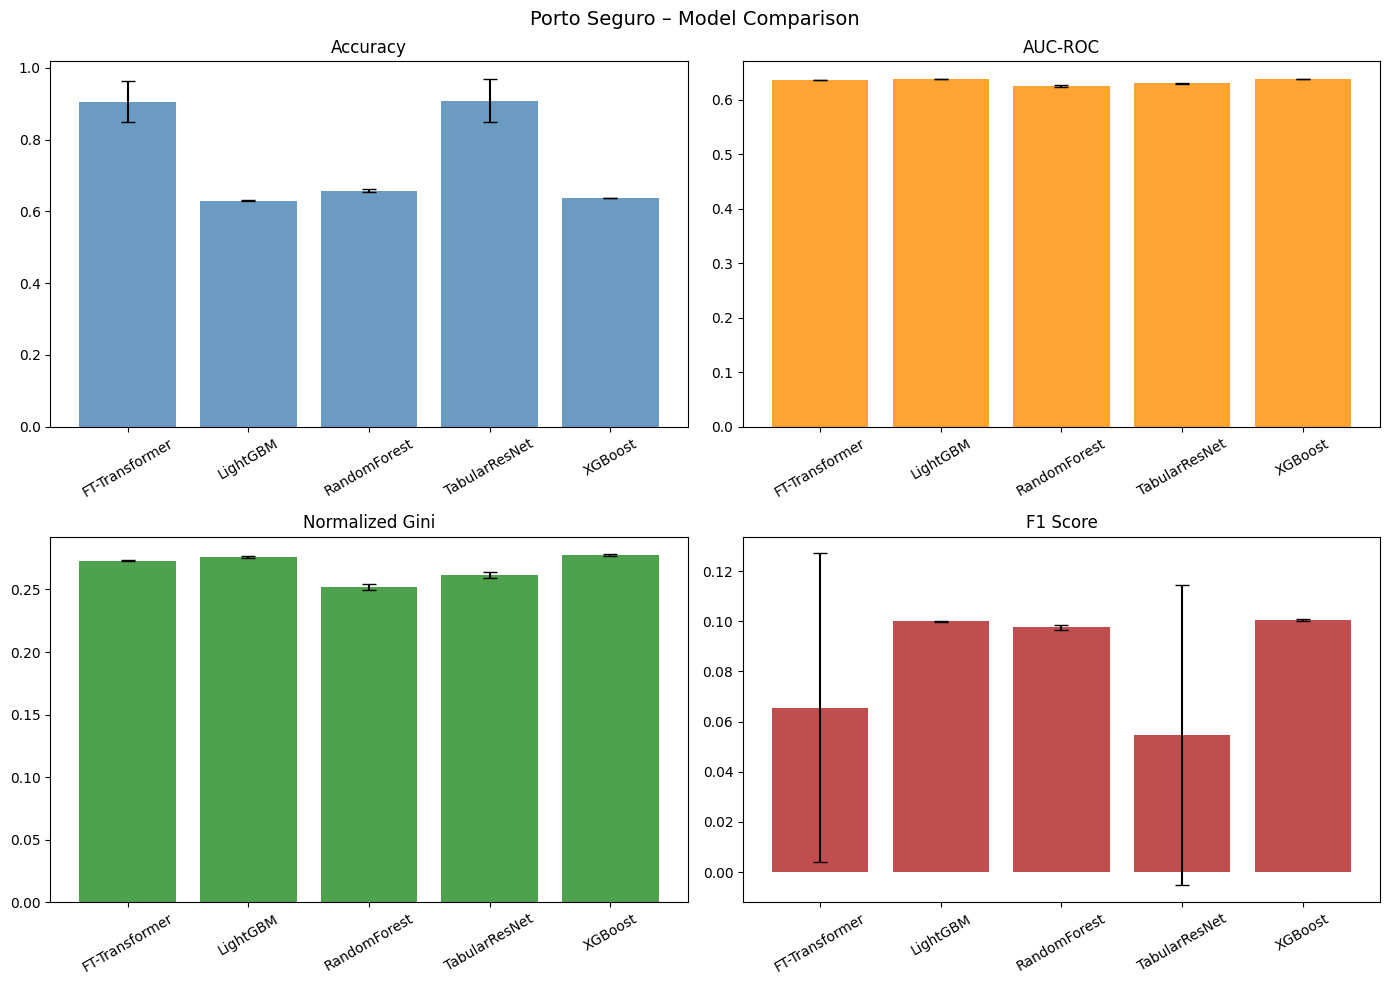

In [87]:
methods = summary.index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].bar(methods, summary['acc_mean'].values, yerr=summary['acc_std'].values,
               capsize=5, color='steelblue', alpha=0.8)
axes[0, 0].set_title('Accuracy')
axes[0, 0].tick_params(axis='x', rotation=30)

axes[0, 1].bar(methods, summary['auc_mean'].values, yerr=summary['auc_std'].values,
               capsize=5, color='darkorange', alpha=0.8)
axes[0, 1].set_title('AUC-ROC')
axes[0, 1].tick_params(axis='x', rotation=30)

axes[1, 0].bar(methods, summary['gini_mean'].values, yerr=summary['gini_std'].values,
               capsize=5, color='forestgreen', alpha=0.8)
axes[1, 0].set_title('Normalized Gini')
axes[1, 0].tick_params(axis='x', rotation=30)

axes[1, 1].bar(methods, summary['f1_mean'].values, yerr=summary['f1_std'].values,
               capsize=5, color='firebrick', alpha=0.8)
axes[1, 1].set_title('F1 Score')
axes[1, 1].tick_params(axis='x', rotation=30)

plt.suptitle('Porto Seguro – Model Comparison', fontsize=14)
plt.tight_layout()
plt.show()


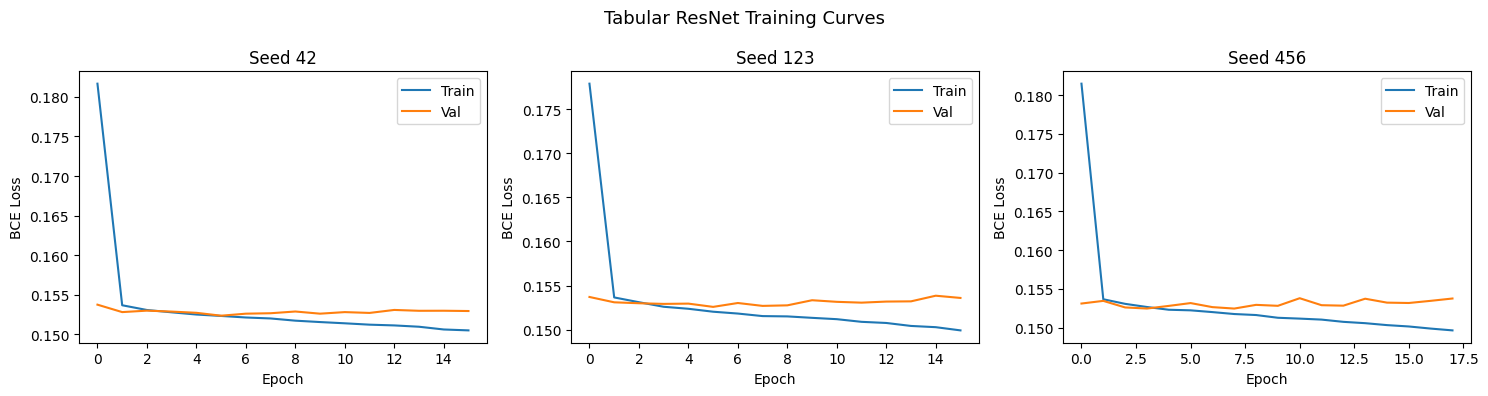

In [88]:
# Tabular ResNet training curves
fig, axes = plt.subplots(1, len(SEEDS), figsize=(15, 4))
for ax, seed in zip(axes, SEEDS):
    tr_l, va_l = rn_train_curves[seed]
    ax.plot(tr_l, label='Train')
    ax.plot(va_l, label='Val')
    ax.set_title(f'Seed {seed}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('BCE Loss')
    ax.legend()
plt.suptitle('Tabular ResNet Training Curves', fontsize=13)
plt.tight_layout()
plt.show()

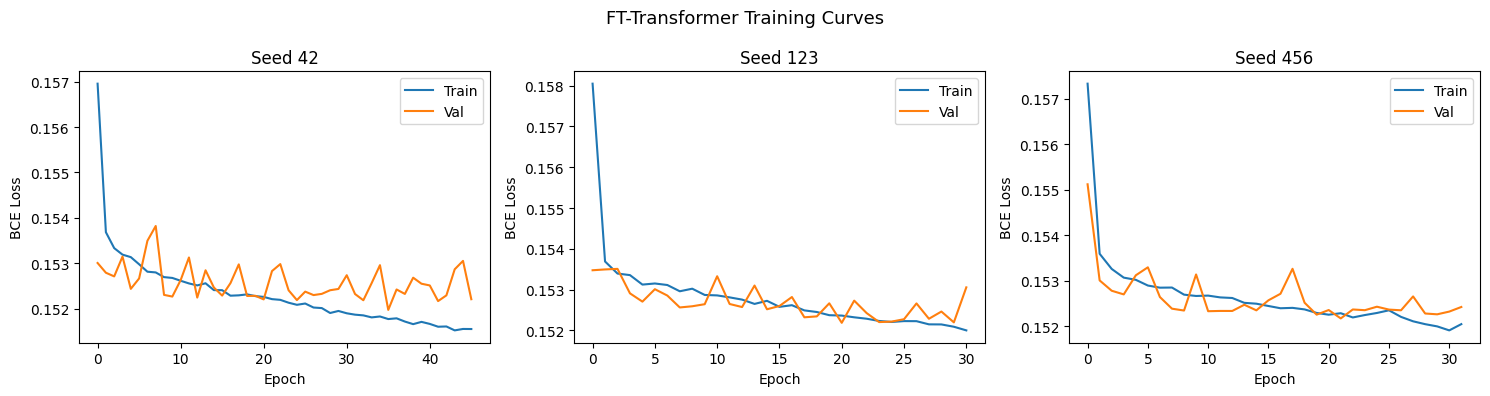

In [89]:
# FT-Transformer training curves
fig, axes = plt.subplots(1, len(SEEDS), figsize=(15, 4))
for ax, seed in zip(axes, SEEDS):
    tr_l, va_l = ft_train_curves[seed]
    ax.plot(tr_l, label='Train')
    ax.plot(va_l, label='Val')
    ax.set_title(f'Seed {seed}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('BCE Loss')
    ax.legend()
plt.suptitle('FT-Transformer Training Curves', fontsize=13)
plt.tight_layout()
plt.show()


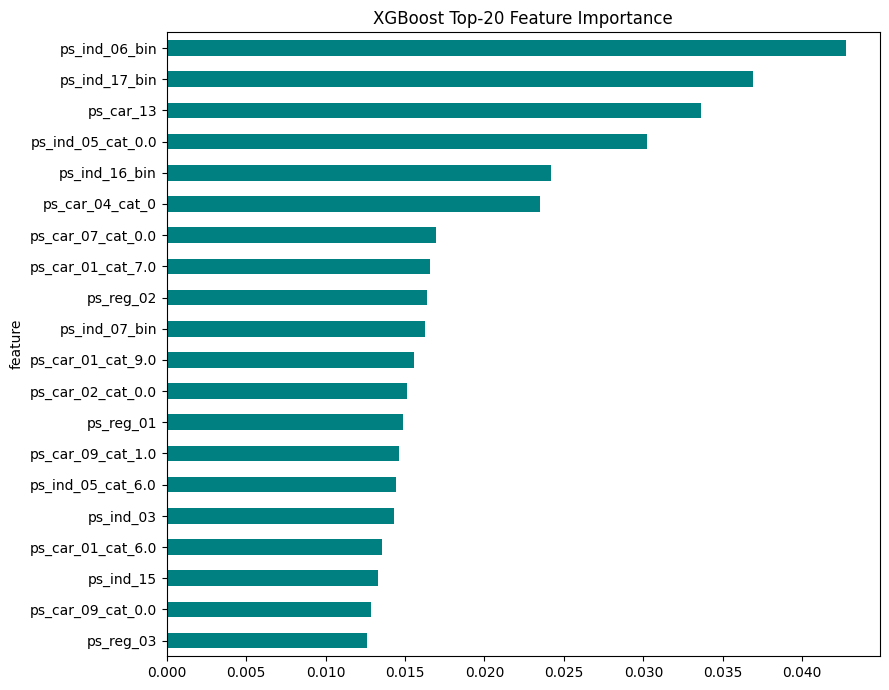

In [90]:
# XGBoost feature importance (top 20)
if xgb_model_last is not None:
    fi = xgb_model_last.feature_importances_
    feat_names = num_cols_ps + onehot_enc_ps.get_feature_names_out(cat_cols_filtered).tolist()
    fi_df = pd.DataFrame({'feature': feat_names, 'importance': fi})
    fi_df = fi_df.sort_values('importance', ascending=True).tail(20)
    fi_df.plot.barh(x='feature', y='importance', figsize=(9, 7),
                    legend=False, color='teal')
    plt.title('XGBoost Top-20 Feature Importance')
    plt.tight_layout()
    plt.show()


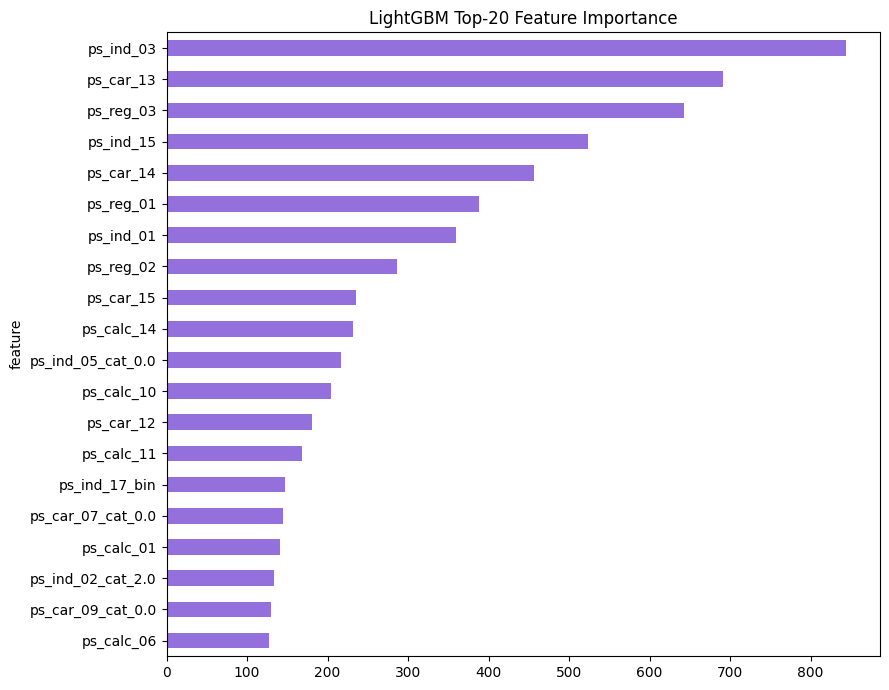

In [91]:
# LightGBM feature importance (top 20)
if lgb_model_last is not None:
    fi = lgb_model_last.feature_importances_
    feat_names = num_cols_ps + onehot_enc_ps.get_feature_names_out(cat_cols_filtered).tolist()
    fi_df = pd.DataFrame({'feature': feat_names, 'importance': fi})
    fi_df = fi_df.sort_values('importance', ascending=True).tail(20)
    fi_df.plot.barh(x='feature', y='importance', figsize=(9, 7),
                    legend=False, color='mediumpurple')
    plt.title('LightGBM Top-20 Feature Importance')
    plt.tight_layout()
    plt.show()


## Analysis & Conclusions

### Summary
We benchmarked five models on the Porto Seguro safe-driver prediction task.

- The dataset is **severely imbalanced** (~3.6 % positive), so **Normalized Gini**
  (= 2·AUC − 1) is the key competition metric.
- **LightGBM** with `is_unbalance=True` and **XGBoost** with `scale_pos_weight`
  are well-suited for this imbalanced setting.
- **FT-Transformer** uses learned categorical embeddings, which can capture
  non-linear interactions between the many categorical features.
- **Tabular ResNet** uses skip connections to learn deep tabular representations.
- **Random Forest** with `class_weight='balanced'` offers a strong tree baseline.

### Observations
- Gini scores on **synthetic** data are near 0 because the synthetic labels are
  random (independent of features). Real data results will differ substantially.
- The preprocessing pipeline — replacing -1 sentinels, mode/median imputation,
  OrdinalEncoding — mirrors common Kaggle solutions for this competition.
- 3-seed evaluation reduces variance in reported Gini.

### Next Steps
- Feature engineering: polynomial interactions among `ps_reg` features.
- Calibrated probability outputs for better threshold tuning.
- Stacking / blending of LightGBM + XGBoost predictions.
- SHAP analysis to understand which feature groups drive predictions.
